## Load bibliotecas

In [49]:
import pandas as pd

from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
dir_datas = Path("../01_databases/reclamacoes_NIP/")
path_files = list(dir_datas.rglob("*.csv"))

In [88]:
df = pd.DataFrame()

for path_file in path_files:
    df = pd.concat([df, pd.read_csv(path_file).drop(['Unnamed: 0'], axis = 1)])

C:\Users\jeffe\AppData\Local\Temp\ipykernel_13816\1193750642.py:4: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([df, pd.read_csv(path_file).drop(['Unnamed: 0'], axis = 1)])
C:\Users\jeffe\AppData\Local\Temp\ipykernel_13816\1193750642.py:4: DtypeWarning: Columns (38,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([df, pd.read_csv(path_file).drop(['Unnamed: 0'], axis = 1)])
C:\Users\jeffe\AppData\Local\Temp\ipykernel_13816\1193750642.py:4: DtypeWarning: Columns (21,33,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([df, pd.read_csv(path_file).drop(['Unnamed: 0'], axis = 1)])
C:\Users\jeffe\AppData\Local\Temp\ipykernel_13816\1193750642.py:4: DtypeWarning: Columns (21,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([df, pd.read_csv(path_file).drop(['Unnamed: 0'], axis = 1)])
C:\U

In [89]:
df.shape

(2174333, 62)

In [98]:
df['MUNIC_CONSUMIDOR_ATEND'] = df['MUNIC_CONSUMIDOR_ATEND'].astype(str)
df['MUNIC_CONSUMIDOR_ATEND'] = df['MUNIC_CONSUMIDOR_ATEND'].fillna("").astype(str)
df['DOCUMENTO_EM_ATE_48H'] = df['DOCUMENTO_EM_ATE_48H'].fillna('').astype('str')

df.to_parquet('../01_databases/reclamacoes_NIP/file_consolidado.parquet', index = False)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2174333 entries, 0 to 377737
Data columns (total 62 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   NUMERO_DA_DEMANDA             int64  
 1   ABERTURA_DA_DEMANDA           object 
 2   ANO_DE_REFERENCIA             int64  
 3   MES_DE_REFERENCIA             int64  
 4   SITUACAO_DA_DEMANDA           object 
 5   TIPO_DE_DEMANDA               object 
 6   PROCEDENCIA_DA_DEMANDA        object 
 7   ENCAMINHADO_PARA_OUVIDORIA    object 
 8   FORMA_DE_CONTATO_COM_A_ANS    object 
 9   PRIORIZACAO_DE_ATENDIMENTO    object 
 10  ASSUNTO                       object 
 11  DT_CONTATO_CONSUM             object 
 12  MOTIVO_DO_CONTATO             object 
 13  CONTATO_BENEF_INTER           object 
 14  CODIGO_OPERADORA              float64
 15  NOME_OPERADORA                object 
 16  MODALIDADE_DA_OPERADORA       object 
 17  TIPO_DE_PLANO_CONTRATADO      object 
 18  EPOCA_DE_ADESAO_AO_PLANO    

In [26]:
df.head()

,NUMERO_DA_DEMANDA,ABERTURA_DA_DEMANDA,ANO_DE_REFERENCIA,MES_DE_REFERENCIA,SITUACAO_DA_DEMANDA,TIPO_DE_DEMANDA,PROCEDENCIA_DA_DEMANDA,ENCAMINHADO_PARA_OUVIDORIA,FORMA_DE_CONTATO_COM_A_ANS,PRIORIZACAO_DE_ATENDIMENTO,...,DATA_DO_ARQUIVAMENTO,INSTANCIA_DO_ARQUIVAMENTO,DT_NOTIFICACAO_MULTA,VALOR_DA_MULTA,DT_DECISAO_2_INSTAN,MULT_MANT_2_INST,DT_CIEN_RECONSIDERACAO,MULTA_ANULADA,DT_ANUL_MULTA,DATA_DE_ATUALIZACAO
0,1346571,2011-10-18,2011,10,Encaminhamento entre Órgãos,Reclamação,E-Mail,NÃO,E-Mail,SIM,...,NaN,NaN,NaN,NaN,NaN,NÃO,NaN,NÃO,NaN,2025-01-05
1,1222131,2011-03-15,2011,3,Procedimento Realizado - Amigável,Reclamação,Pessoal,NÃO,Pessoal,SIM,...,NaN,NaN,NaN,NaN,NaN,NÃO,NaN,NÃO,NaN,2025-01-05
2,1378271,2011-12-13,2011,12,Arquivamento,Reclamação,E-Mail,NÃO,E-Mail,NÃO,...,NaN,ARQ/CENTRAL,NaN,NaN,NaN,NÃO,NaN,NÃO,NaN,2025-01-05
3,1338595,2011-10-03,2011,10,Encaminhamento entre Órgãos,Reclamação,Telefone,NÃO,Telefone,SIM,...,NaN,NaN,NaN,NaN,NaN,NÃO,NaN,NÃO,NaN,2025-01-05
4,1364308,2011-11-18,2011,11,Procedimento Realizado - Amigável,Reclamação,Telefone,NÃO,Telefone,SIM,...,NaN,NaN,NaN,NaN,NaN,NÃO,NaN,NÃO,NaN,2025-01-05


In [25]:
df['ABERTURA_DA_DEMANDA'] = df['ABERTURA_DA_DEMANDA'].astype('datetime64[ns]')

In [36]:
df['MODALIDADE_DA_OPERADORA'].value_counts()

MODALIDADE_DA_OPERADORA
Medicina de Grupo                    1005181
Cooperativa Médica                    565188
Seguradora Especializada em Saúde     381448
Autogestão                            113479
Administradora de Benefícios           65056
Filantropia                            19356
Seguradora                               235
Administradora                            22
Name: count, dtype: int64

In [34]:
df['MODALIDADE_DA_OPERADORA'] = df['MODALIDADE_DA_OPERADORA'].str.strip()

In [35]:
df = df[~df['MODALIDADE_DA_OPERADORA'].isin(['Cooperativa odontológica', 'Odontologia de Grupo'])]

In [43]:
dfgrp_st_dem = df[['SITUACAO_DA_DEMANDA']].value_counts().reset_index().merge(df[['SITUACAO_DA_DEMANDA']].value_counts(normalize=True), on = 'SITUACAO_DA_DEMANDA')

top_10 = dfgrp_st_dem['SITUACAO_DA_DEMANDA'].head(10).to_list()

In [ ]:
dfgrp_st_dem = df[['SITUACAO_DA_DEMANDA']].value_counts().reset_index().merge(df[['SITUACAO_DA_DEMANDA']].value_counts(normalize=True), on = 'SITUACAO_DA_DEMANDA')

top_10 = dfgrp_st_dem['SITUACAO_DA_DEMANDA'].head(10).to_list()

In [48]:
dfgrp_st_dem = df[['ANO_DE_REFERENCIA', 'SITUACAO_DA_DEMANDA']].value_counts().reset_index()

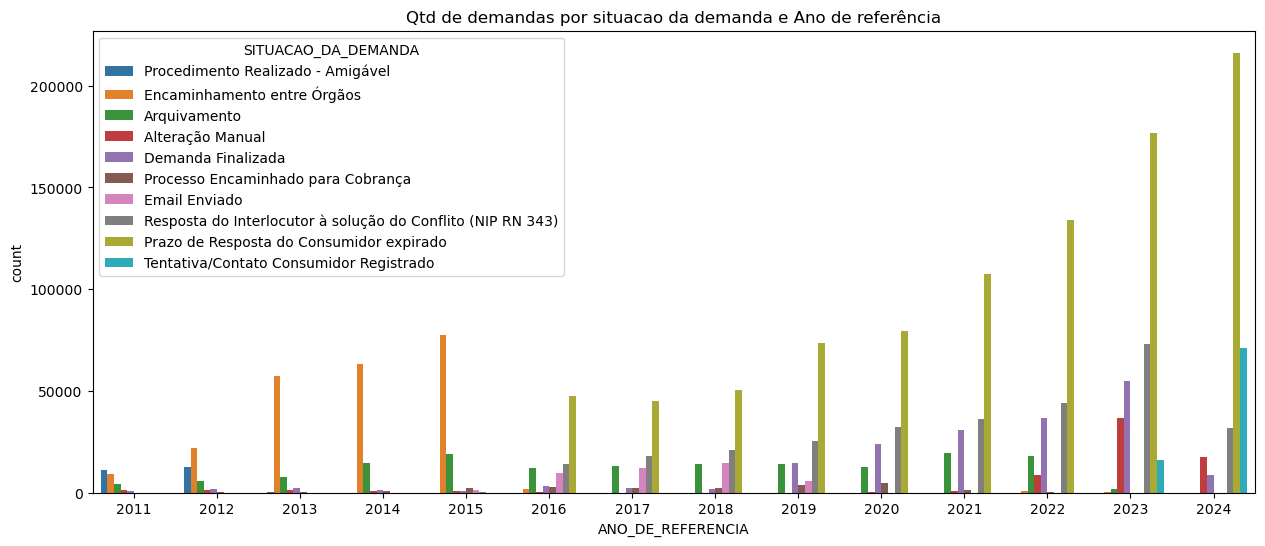

In [58]:
plt.figure(figsize=(15, 6))

ax = sns.barplot(data = dfgrp_st_dem[dfgrp_st_dem['SITUACAO_DA_DEMANDA'].isin(top_10)], x = 'ANO_DE_REFERENCIA', y = 'count', hue = 'SITUACAO_DA_DEMANDA')
ax.set_title('Qtd de demandas por situacao da demanda e Ano de referência')
plt.show()

In [62]:
dfgrp_st_dem['perc_situacao'] = dfgrp_st_dem['count']/dfgrp_st_dem.groupby('SITUACAO_DA_DEMANDA')['count'].transform('sum')

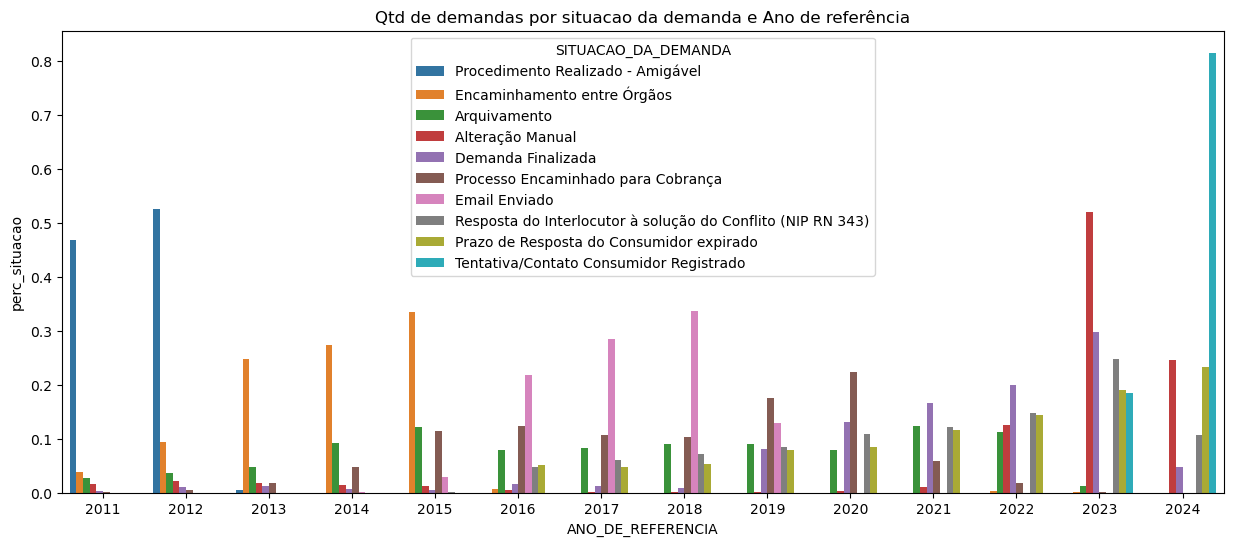

In [64]:
plt.figure(figsize=(15, 6))

ax = sns.barplot(data = dfgrp_st_dem[dfgrp_st_dem['SITUACAO_DA_DEMANDA'].isin(top_10)], x = 'ANO_DE_REFERENCIA', y = 'perc_situacao', hue = 'SITUACAO_DA_DEMANDA')
ax.set_title('Qtd de demandas por situacao da demanda e Ano de referência')
plt.show()

In [76]:
df.isna().sum().reset_index().rename({0:"qtd_na"}, axis = 1).query("qtd_na > 0")


,index,qtd_na
11,DT_CONTATO_CONSUM,222482
14,CODIGO_OPERADORA,268
15,NOME_OPERADORA,268
16,MODALIDADE_DA_OPERADORA,268
17,TIPO_DE_PLANO_CONTRATADO,45025
19,TIPOS_DE_COBER_CONTRATADAS,45025
20,NOME_DA_ADMIN_DE_BENEFICIO,2150021
21,DT_DE_NASCIMENTO_DO_BENEF,862
22,SEXO,9712
23,ESTADO_DO_BENEFICIARIO,6591


In [77]:
print(df.columns)

Index(['NUMERO_DA_DEMANDA', 'ABERTURA_DA_DEMANDA', 'ANO_DE_REFERENCIA',
       'MES_DE_REFERENCIA', 'SITUACAO_DA_DEMANDA', 'TIPO_DE_DEMANDA',
       'PROCEDENCIA_DA_DEMANDA', 'ENCAMINHADO_PARA_OUVIDORIA',
       'FORMA_DE_CONTATO_COM_A_ANS', 'PRIORIZACAO_DE_ATENDIMENTO', 'ASSUNTO',
       'DT_CONTATO_CONSUM', 'MOTIVO_DO_CONTATO', 'CONTATO_BENEF_INTER',
       'CODIGO_OPERADORA', 'NOME_OPERADORA', 'MODALIDADE_DA_OPERADORA',
       'TIPO_DE_PLANO_CONTRATADO', 'EPOCA_DE_ADESAO_AO_PLANO',
       'TIPOS_DE_COBER_CONTRATADAS', 'NOME_DA_ADMIN_DE_BENEFICIO',
       'DT_DE_NASCIMENTO_DO_BENEF', 'SEXO', 'ESTADO_DO_BENEFICIARIO',
       'MUNICIPIO_DO_BENEFICIARIO', 'CODIGO_MUNICIPIO', 'NOME_DO_PROCEDIMENTO',
       'UF_ONDE_CONSUMIDOR', 'MUNIC_CONSUMIDOR_ATEND', 'DT_INTERLOCUTOR',
       'HORA_EM_QUE_O_CONSUMIDOR', 'TIPO_DE_ATENDIMENTO',
       'DOCUMENTO_EM_ATE_48H', 'NUMERO_DA_NIP', 'DATA_DE_ENVIO_DA_NIP',
       'CLASSIFICACAO_DA_NIP', 'NATUREZA_DA_NIP', 'DATA_DE_RETORNO_DA_NIP',
       'SITUA

In [79]:
df['NUMERO_DA_NIP'].value_counts().reset_index().query('count > 1')

,NUMERO_DA_NIP,count
0,2965374,124
1,3153062,116
2,5306447,63
3,2650734,62
4,4174391,60
...,...,...
70170,5989667,2
70171,4098026,2
70172,3825895,2
70173,5753454,2


In [87]:
pd.options.display.max_columns = 999

df[df['NUMERO_DA_NIP'] == 2965374].head(2)

,NUMERO_DA_DEMANDA,ABERTURA_DA_DEMANDA,ANO_DE_REFERENCIA,MES_DE_REFERENCIA,SITUACAO_DA_DEMANDA,TIPO_DE_DEMANDA,PROCEDENCIA_DA_DEMANDA,ENCAMINHADO_PARA_OUVIDORIA,FORMA_DE_CONTATO_COM_A_ANS,PRIORIZACAO_DE_ATENDIMENTO,ASSUNTO,DT_CONTATO_CONSUM,MOTIVO_DO_CONTATO,CONTATO_BENEF_INTER,CODIGO_OPERADORA,NOME_OPERADORA,MODALIDADE_DA_OPERADORA,TIPO_DE_PLANO_CONTRATADO,EPOCA_DE_ADESAO_AO_PLANO,TIPOS_DE_COBER_CONTRATADAS,NOME_DA_ADMIN_DE_BENEFICIO,DT_DE_NASCIMENTO_DO_BENEF,SEXO,ESTADO_DO_BENEFICIARIO,MUNICIPIO_DO_BENEFICIARIO,CODIGO_MUNICIPIO,NOME_DO_PROCEDIMENTO,UF_ONDE_CONSUMIDOR,MUNIC_CONSUMIDOR_ATEND,DT_INTERLOCUTOR,HORA_EM_QUE_O_CONSUMIDOR,TIPO_DE_ATENDIMENTO,DOCUMENTO_EM_ATE_48H,NUMERO_DA_NIP,DATA_DE_ENVIO_DA_NIP,CLASSIFICACAO_DA_NIP,NATUREZA_DA_NIP,DATA_DE_RETORNO_DA_NIP,SITUACAO_DA_NIP,HOUVE_ENCAMIN_AO_NUCLEO,DATA_DO_AUTO,ORGAO_GERADOR,NUMERO_AUTO,STATUS_AUTO,STATUS_ANULADO,DATA_EMISSAO_DO_AUTO,DT_ANUL_AUTO,NUMERO_PROCESSO,QUAL_NUCLEO_APUROU_A_DEMANDA,DT_1_INSTANCIA,TIPO_DE_PENALIDADE,VALOR_DO_DESCONTO,DATA_DO_ARQUIVAMENTO,INSTANCIA_DO_ARQUIVAMENTO,DT_NOTIFICACAO_MULTA,VALOR_DA_MULTA,DT_DECISAO_2_INSTAN,MULT_MANT_2_INST,DT_CIEN_RECONSIDERACAO,MULTA_ANULADA,DT_ANUL_MULTA,DATA_DE_ATUALIZACAO
7812,2965374,2016-01-20,2016,1,Arquivamento,Reclamação,Telefone,NÃO,Telefone,SIM,Produto ou Plano >> Cobertura >> Regras para A...,2016-01-12,Reclamação,Interlocutor,326305.0,AMIL ASSISTÊNCIA MÉDICA INTERNACIONAL S.A.,Medicina de Grupo,Individual ou Familiar,-,Ambulatorial + Hospitalar c/ Obstetrícia (A) +...,NaN,1987-04-14,F,SP,SAO CAETANO DO SUL ...,355030.0,URÉIA,SAOPAULO,ABC,2016-01-12,NaN,Reclamação,NaN,2965374,2016-01-20,NÚCLEO,Assistencial,NaN,Arquivado,NÃO,2016-09-13,NUCLEO-SP,127672016.0,Cancelado,NÃO,2016-09-13,2016-11-14,25789.018280/2016-99,NUCLEO-SP,2016-11-14,Multa Pecuniária,40%,2017-03-07,ARQ/NUCLEO-SP,2016-11-22,80000.0,NaN,NÃO,NaN,NÃO,NaN,2025-01-05
7813,2965374,2016-01-20,2016,1,Arquivamento,Reclamação,Telefone,NÃO,Telefone,SIM,Produto ou Plano >> Cobertura >> Regras para A...,2016-01-12,Reclamação,Interlocutor,326305.0,AMIL ASSISTÊNCIA MÉDICA INTERNACIONAL S.A.,Medicina de Grupo,Individual ou Familiar,-,Ambulatorial + Hospitalar c/ Obstetrícia (A) +...,NaN,1987-04-14,F,SP,SAO CAETANO DO SUL ...,355030.0,FERRO SÉRICO,SAOPAULO,ABC,2016-01-12,NaN,Reclamação,NaN,2965374,2016-01-20,NÚCLEO,Assistencial,NaN,Arquivado,NÃO,2016-09-13,NUCLEO-SP,127672016.0,Cancelado,NÃO,2016-09-13,2016-11-14,25789.018280/2016-99,NUCLEO-SP,2016-11-14,Multa Pecuniária,NaN,2017-03-07,ARQ/NUCLEO-SP,2016-11-22,80000.0,NaN,NÃO,NaN,NÃO,NaN,2025-01-05


In [82]:
df.drop_duplicates(inplace=True)

In [83]:
df['NUMERO_DA_NIP'].value_counts().reset_index().query('count > 1')

,NUMERO_DA_NIP,count
0,2965374,124
1,3153062,116
2,5306447,63
3,2650734,62
4,4174391,60
...,...,...
70079,3073633,2
70080,1597427,2
70081,5275107,2
70082,2323534,2
